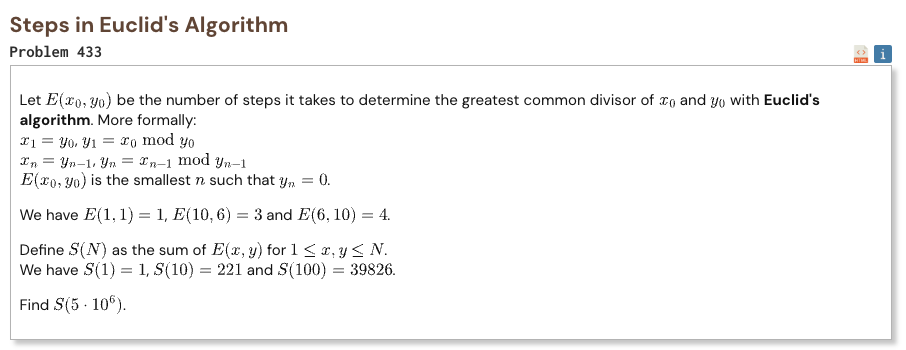

## Initial approach

-   calculate the answer one row at a time instead of storing every pair
-   use symmetry so only pairs where the first number is larger need to be checked
-   run Euclid's algorithm directly for each pair and count its steps
-   add the diagonal pairs separately since each of them takes one step
-   pairs in the opposite triangle take one extra step after swapping their order
-   use numba to compile the heavy nested loops into fast machine code
-   this uses numba because normal Python loops are far too slow for millions of values

```python
%%time

from numba import njit

@njit
def solve(N):
    lower_sum = 0

    for x in range(2, N + 1):
        for y in range(1, x):
            a = x
            b = y
            steps = 0

            while b:
                a, b = b, a % b
                steps += 1

            lower_sum += steps

    result = 2 * lower_sum + N * (N + 1) // 2

    return result

N = 5_000_000
result = solve(N)

print("Result:", result)
```

it performs trillios of pair checks. needs an optimization.